## Regime Detection in Financial Markets using Machine Learning (Visualisation)
- Author: Abbinav Sankar Kailasam (UCL)
- Supervisors: Dr. Blaz Zlicar (ADIA), Prof. Fabio Caccioli (UCL)

In [ ]:
# Import the necessary libraries
import os
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import matplotlib.animation as animation
import seaborn as sns
import networkx as nx

from networks import load_arm

GIF_DIR = "presentation"
os.makedirs(GIF_DIR, exist_ok=True)

In [2]:
SECTOR_LABELS = {
    "SP500": {
        "IT": "Information Technology",
        "HC": "Health Care",
        "FIN": "Financials",
        "CD": "Consumer Discretionary",
        "CS": "Communication Services",
        "IND": "Industrials",
        "CST": "Consumer Staples",
        "ENE": "Energy",
        "UTL": "Utilities",
        "RE": "Real Estate",
        "MAT": "Materials",
    },
    "Nikkei225": {
        "PHARMA": "Pharmaceuticals",
        "ELECMC": "Electric Machinery",
        "AUTO": "Automobiles & Auto Parts",
        "PRECIS": "Precision Instruments",
        "COMMS": "Communications",
        "BANK": "Banking",
        "OTHFIN": "Other Financial Services",
        "SECUR": "Securities",
        "INSUR": "Insurance",
        "FISH": "Fishery, Agriculture & Forestry",
        "FOODS": "Foods",
        "RETAIL": "Retail Trade",
        "SERVIC": "Services",
        "MINING": "Mining",
        "TEXTIL": "Textiles & Apparel",
        "PULP": "Pulp & Paper",
        "CHEMIC": "Chemicals",
        "PETROL": "Oil & Coal Products",
        "RUBBER": "Rubber Products",
        "GLASS": "Glass & Ceramics",
        "STEEL": "Iron & Steel",
        "NONFER": "Nonferrous Metals",
        "TRADCO": "Trading Companies",
        "CONSTR": "Construction",
        "MACHIN": "Machinery",
        "SHIPBD": "Shipbuilding",
        "OTHMFG": "Other Manufacturing",
        "REALES": "Real Estate",
        "RAILBS": "Railroad & Bus",
        "LANDTR": "Land Transportation",
        "MARINE": "Marine Transportation",
        "AIRTR": "Air Transportation",
        "ELECPW": "Electric Power",
        "GAS": "Gas",
    },
    "FTSE350": {
        "IND": "Industrials",
        "ENE": "Energy",
        "CD": "Consumer Discretionary",
        "FIN": "Financials",
        "MAT": "Materials",
        "CST": "Consumer Staples",
        "UTL": "Utilities",
        "HC": "Health Care",
        "TECH": "Technology",
        "TEL": "Telecommunications",
        "RE": "Real Estate",
    },
    "CSI300": {
        "IT": "Information Technology",
        "IND": "Industrials",
        "FIN": "Financials",
        "MAT": "Materials",
        "HC": "Health Care",
        "CST": "Consumer Staples",
        "CD": "Consumer Discretionary",
        "UTL": "Utilities",
        "ENE": "Energy",
        "CS": "Communication",
        "RE": "Real Estate",
    },
}

INDICES = ["SP500", "Nikkei225", "FTSE350", "CSI300"]
EPOCH_CONFIGS = [(132, 10)]
GRAPH_LABELS = {"threshold": "Threshold", "mst": "MST-Threshold", "tmfg": "TMFG-Threshold"}

In [ ]:
def build_animation(index_code, epoch_length, epoch_shift):
    data = load_arm("raw", epoch_length, index_code=index_code)

    correlations, mu_values, dates = data["correlation_matrices"], data["mu_values"], data["epoch_dates"]
    construction_graphs = {
        "threshold": data["threshold_graphs"],
        "mst": data["mst_threshold_graphs"],
        "tmfg": data["tmfg_threshold_graphs"],
    }

    stock_names = data["stock_names"]
    sector_labels = SECTOR_LABELS[index_code]
    stock_sector = {s: s.split("_")[0] for s in stock_names}
    unique_sectors = sorted(set(stock_sector.values()))
    sector_colors_map = dict(zip(unique_sectors, sns.color_palette("husl", len(unique_sectors))))
    node_colors = {s: sector_colors_map[stock_sector[s]] for s in stock_names}

    plt.style.use("default")
    fig = plt.figure(figsize=(18, 10), facecolor="white")
    gs = fig.add_gridspec(2, 3, height_ratios=[1, 1.2])
    ax1, ax2, ax3 = (fig.add_subplot(gs[0, i]) for i in range(3))
    ax4, ax5, ax6 = (fig.add_subplot(gs[1, i]) for i in range(3))
    fig.subplots_adjust(hspace=0.12, wspace=0.05, right=0.92)

    pos = nx.kamada_kawai_layout(construction_graphs["tmfg"][0], weight="weight")

    sm = plt.cm.ScalarMappable(cmap="jet", norm=plt.Normalize(vmin=-1, vmax=1))
    cbar_ax = fig.add_axes([0.94, 0.55, 0.015, 0.33])
    fig.colorbar(sm, cax=cbar_ax, label="correlation")

    sector_legend = [Patch(facecolor=sector_colors_map[s], label=sector_labels.get(s, s)) for s in unique_sectors]
    fig.legend(handles=sector_legend, loc="lower center", ncol=min(len(unique_sectors), 8), fontsize=8, frameon=False)

    def draw_net(G, ax, mu_val):
        nx.draw_networkx_edges(G, pos, ax=ax, edge_color="black", width=0.6, alpha=0.5)
        nx.draw_networkx_nodes(G, pos, ax=ax, node_color=[node_colors[n] for n in G.nodes()],
                                node_size=35, alpha=0.9, linewidths=0)
        ax.text(0.02, 0.98, f"μ = {mu_val:.3f}", transform=ax.transAxes, va="top", fontsize=10,
                bbox=dict(facecolor="white", alpha=0.85, edgecolor="lightgray"))
        ax.text(0.02, 0.88, f"ρ = {nx.density(G):.3f}", transform=ax.transAxes, va="top", fontsize=10,
                bbox=dict(facecolor="white", alpha=0.85, edgecolor="lightgray"))
        ax.axis("off")

    def update(frame):
        for ax in (ax1, ax2, ax3, ax4, ax5, ax6):
            ax.clear()

        C = correlations[frame]
        for ax, key in ((ax1, "threshold"), (ax2, "mst"), (ax3, "tmfg")):
            ax.imshow(C, cmap="jet", vmin=-1, vmax=1)
            ax.set_title(GRAPH_LABELS[key]); ax.set_xticks([]); ax.set_yticks([])

        draw_net(construction_graphs["threshold"][frame], ax4, mu_values[frame])
        draw_net(construction_graphs["mst"][frame], ax5, mu_values[frame])
        draw_net(construction_graphs["tmfg"][frame], ax6, mu_values[frame])

        fig.suptitle(f"{index_code} — Threshold vs MST-Threshold vs TMFG-Threshold (T={epoch_length}, S={epoch_shift})\n"
                     f"{dates[frame].date()}", fontsize=15, fontweight="bold", y=0.98)

    ani = animation.FuncAnimation(fig, update, frames=len(correlations), interval=120, repeat=True)
    out_name = os.path.join(GIF_DIR, f"{index_code}_Threshold_vs_MST_vs_TMFG_{epoch_length}d.gif")
    ani.save(out_name, writer="pillow", fps=12)
    plt.show()
    plt.close(fig)
    print(f"saved {out_name}")

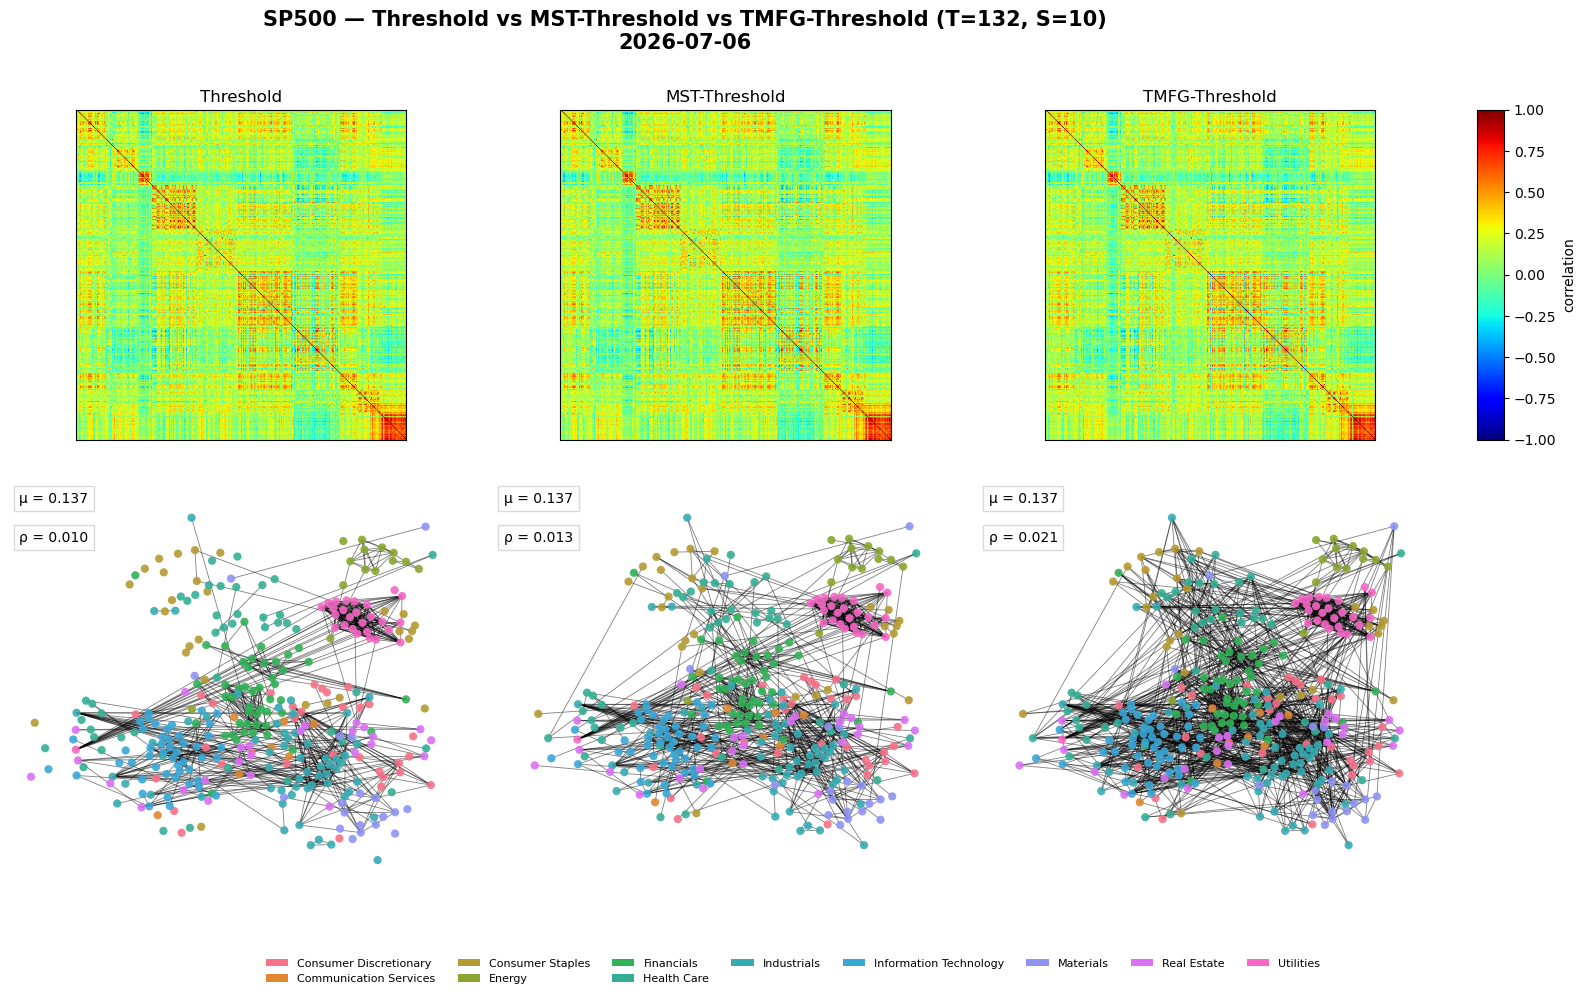

saved SP500_Threshold_vs_MST_vs_TMFG_132d.gif


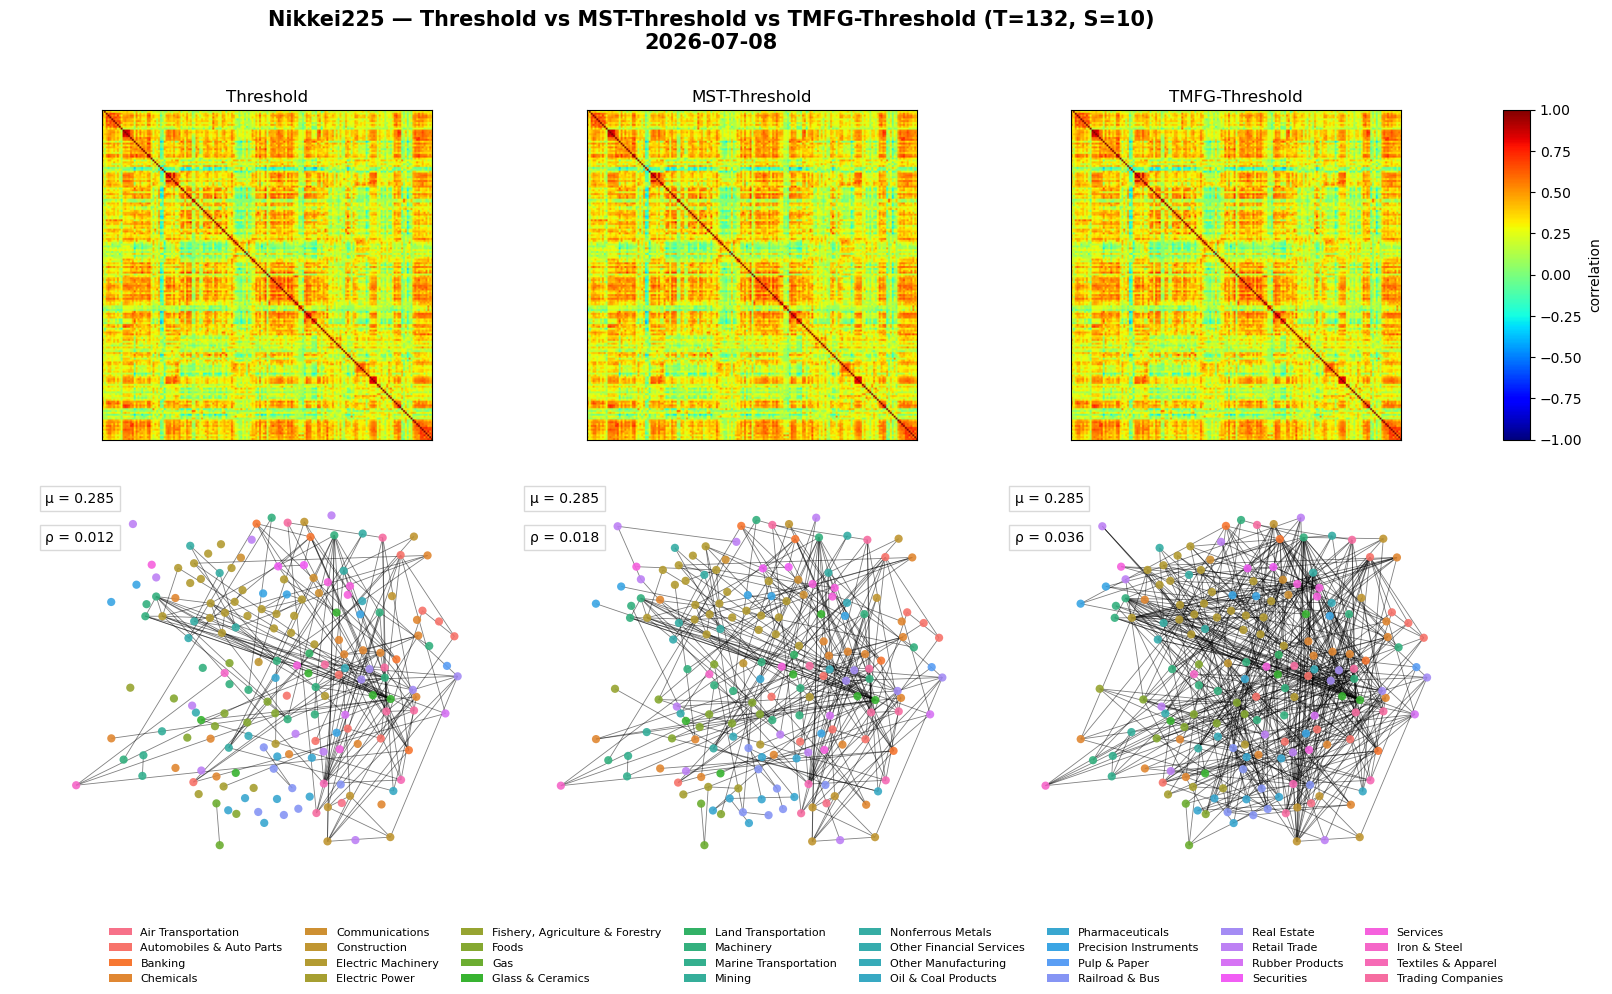

saved Nikkei225_Threshold_vs_MST_vs_TMFG_132d.gif


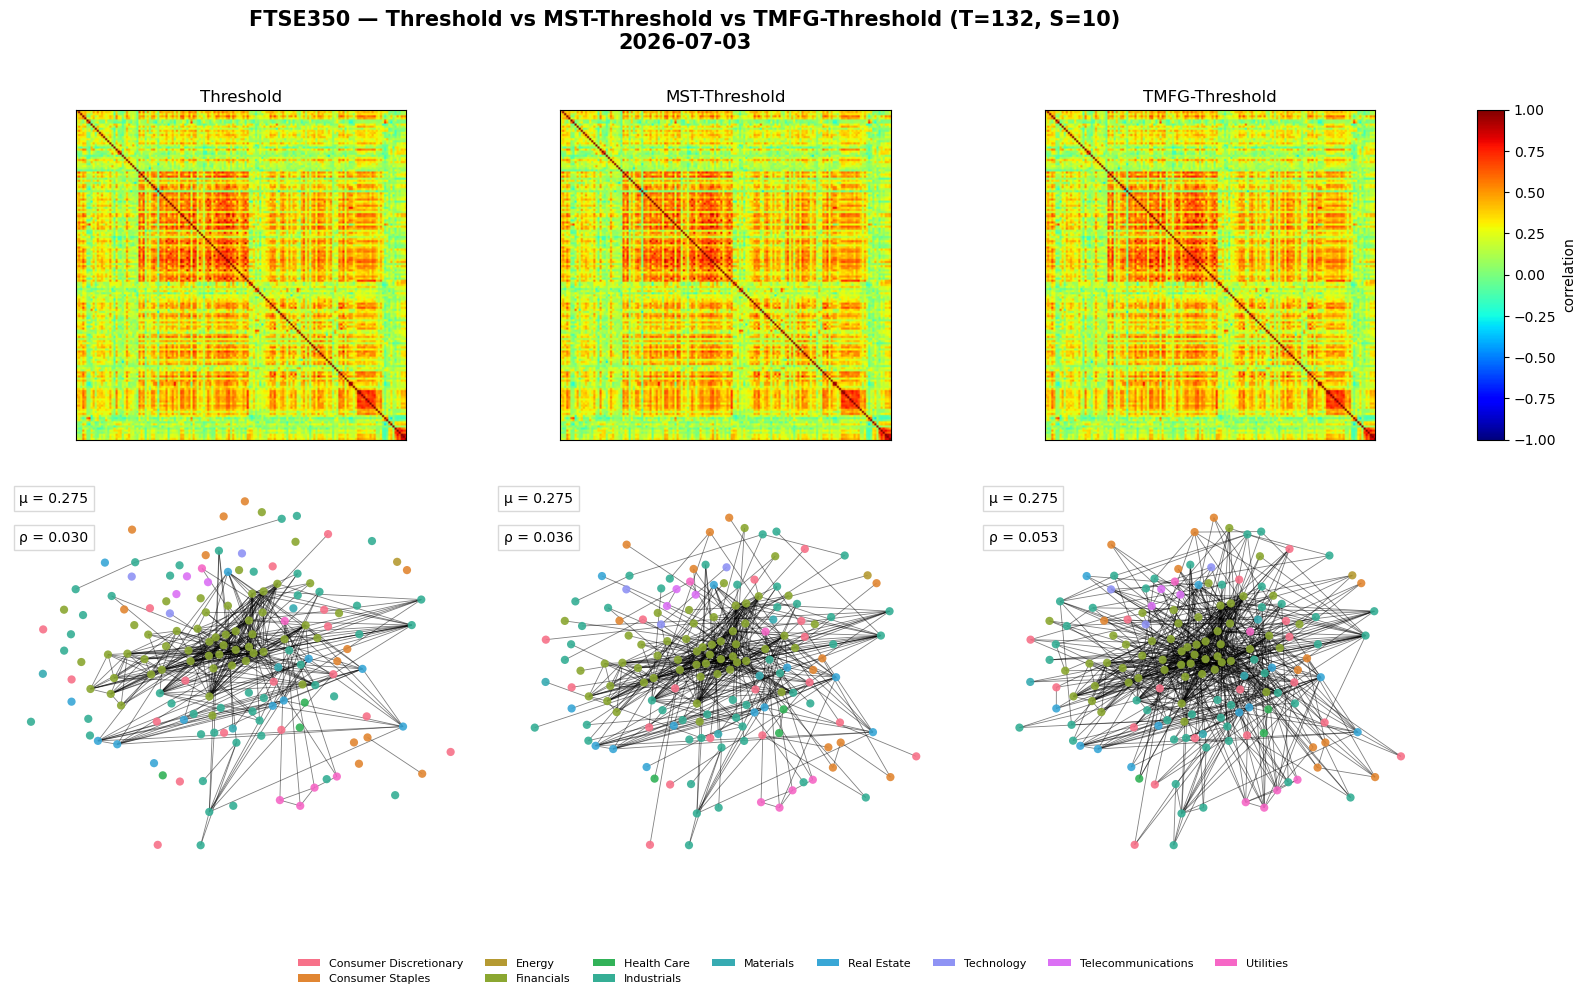

saved FTSE350_Threshold_vs_MST_vs_TMFG_132d.gif


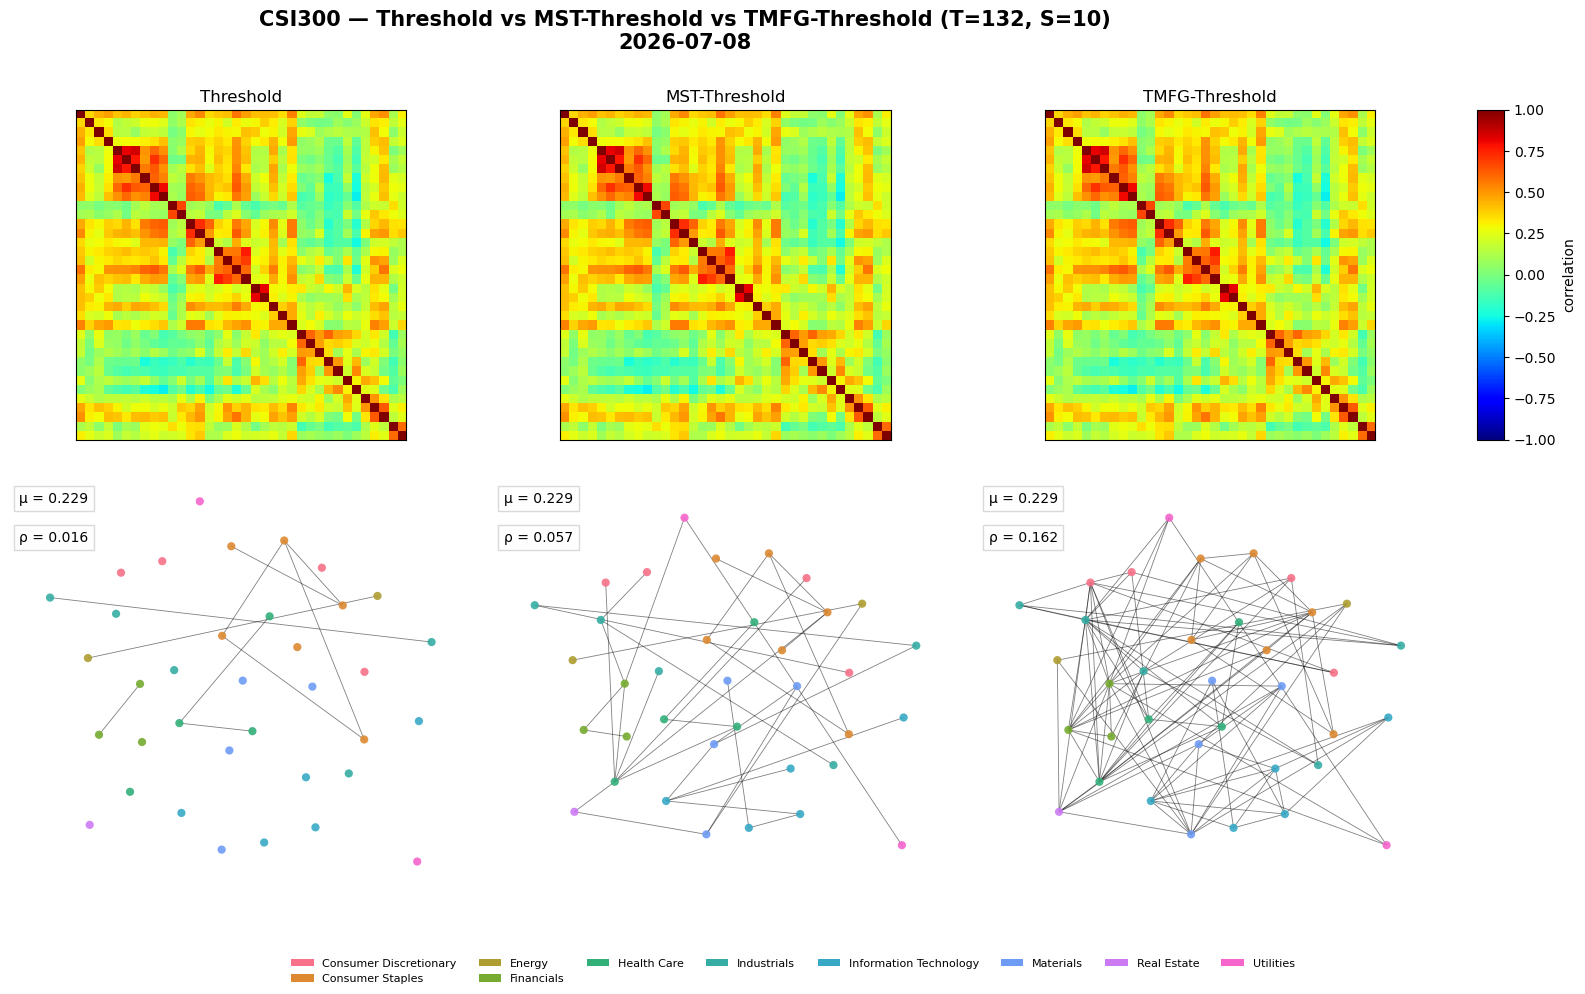

saved CSI300_Threshold_vs_MST_vs_TMFG_132d.gif


In [4]:
for epoch_length, epoch_shift in EPOCH_CONFIGS:
    for index_code in INDICES:
        build_animation(index_code, epoch_length, epoch_shift)